**Метод Дихотомии**

In [92]:
def dichotomy(f, a, b, eps):
    iterations = 0
    while b - a > eps:
        iterations += 1
        c = (a + b) / 2
        if f(c - eps) < f(c + eps):
            b = c
        else:
            a = c
    return ((a + b) / 2, iterations)

**Метод Фибоначчи**

In [93]:
def fibonacci(f, a, b, eps):
    iterations = 0
    fib = [1, 1]
    while (b - a) / fib[-1] > eps:
        fib.append(fib[-1] + fib[-2])
    n = len(fib) - 1
    
    d = (b - a)/fib[n]
    x1 = a + fib[n-2] * d
    x2 = b - fib[n-2] * d
    f1, f2 = f(x1), f(x2)
    
    for k in range(n-2):
        iterations += 1
        if f1 > f2:
            a, x1, f1 = x1, x2, f2
            x2 = b - fib[n-k-3] * d
            f2 = f(x2)
        else:
            b, x2, f2 = x2, x1, f1
            x1 = a + fib[n-k-3] * d
            f1 = f(x1)
    
    return ((a + b) / 2 if f1 < f2 else (x1 + b) / 2, iterations)

**Метод Золотого сечения**

In [94]:
def golden_section(f, a, b, eps):
    iterations = 0
    phi = 0.382
    x1 = a + phi * (b - a)
    x2 = b -  phi * (b - a)
    f1, f2 = f(x1), f(x2)
    
    while b - a > eps:
        iterations += 1
        if f1 > f2:
            a, x1, f1 = x1, x2, f2
            x2 = b - phi * (b - a)
            f2 = f(x2)
        else:
            b, x2, f2 = x2, x1, f1
            x1 = a + phi * (b - a)
            f1 = f(x1)
    
    return ((a + b) / 2, iterations)

**Исходные данные**

In [95]:
def f(x):
    return (x - 2)**2

a = 0
b = 3
eps = [0.1, 0.01, 0.001, 1e-9]

**Тесты**

In [96]:
import pandas as pd

tests_df = {
    "Eps":[],
    "Dichotomy results":[],
    "Dichotomy iterations":[],
    "Fibonacci results":[],
    "Fibonacci iterations":[],
    "Golden Section results":[],
    "Golden Section iterations":[]
}

tests_df = pd.DataFrame(tests_df)

In [97]:
for k in eps:

    dichotomy_res = dichotomy(f, a, b, k)
    fibonacci_res = fibonacci(f, a, b, k)
    golden_section_res = golden_section(f, a, b, k)

    tests_df.loc[len(tests_df)] = [k, dichotomy_res[0], dichotomy_res[1], fibonacci_res[0], fibonacci_res[1], golden_section_res[0], golden_section_res[1]]

tests_df

,Eps,Dichotomy results,Dichotomy iterations,Fibonacci results,Fibonacci iterations,Golden Section results,Golden Section iterations
0,1.000000e-01,2.015625,5.0,2.073529,6.0,1.989315,8.0
1,1.000000e-02,2.000977,9.0,1.997347,11.0,2.001504,12.0
2,1.000000e-03,1.999878,12.0,2.000120,16.0,1.999994,17.0
3,1.000000e-09,2.000000,32.0,2.000000,45.0,2.000001,42.0


In [98]:
import time

def measure_time(func, *args, **kwargs):
    start = time.perf_counter()
    result = func(*args, **kwargs)
    end = time.perf_counter()
    return result, end - start

res_dich, t_dich = measure_time(dichotomy, f, a, b, 1e-10)
res_fib, t_fib = measure_time(fibonacci, f, a, b, 1e-10)
res_gold, t_gold = measure_time(golden_section, f, a, b, 1e-10)

print(f"Дихотомия: {res_dich[0]:.6f}, время: {t_dich:.6f}")
print(f"Фибоначчи: {res_fib[0]:.6f}, время: {t_fib:.6f}")
print(f"Золотое сечение: {res_gold[0]:.6f}, время: {t_gold:.6f}")

Дихотомия: 2.000000, время: 0.000019
Фибоначчи: 2.000000, время: 0.000023
Золотое сечение: 2.000001, время: 0.000013


In [99]:
import matplotlib.pyplot as plt
import numpy as np

def visualize(method, name):
    a = 0
    b = 3
    x = np.linspace(1e-9, 0.1, 10)
    iterations = [method(f, a, b, e)[1] for e in x]
    y = np.log(x)

    plt.figure(figsize=(8, 5))
    plt.plot(x, y, 'o-', label='y = ln(x)', color='blue', linewidth=2)
    plt.plot(iterations, y, 'o-', label='iterations', color='red', linewidth=3)

    plt.axhline(0, color='black', linewidth=1)
    plt.axvline(0, color='black', linewidth=1)

    plt.title(name)
    plt.xlabel('x')
    plt.ylabel('y')
    plt.legend()
    plt.show()

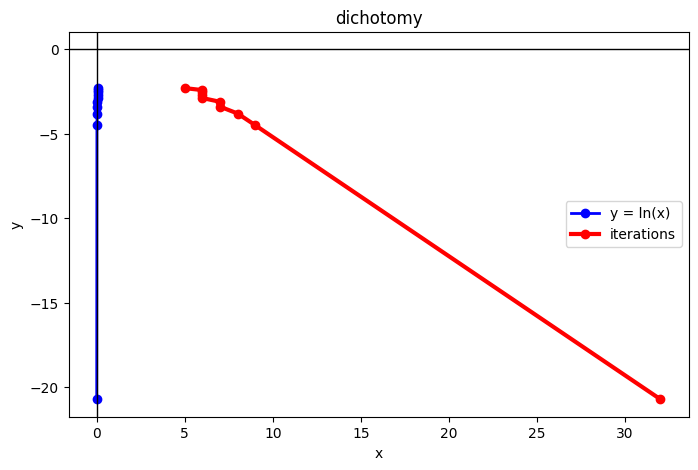

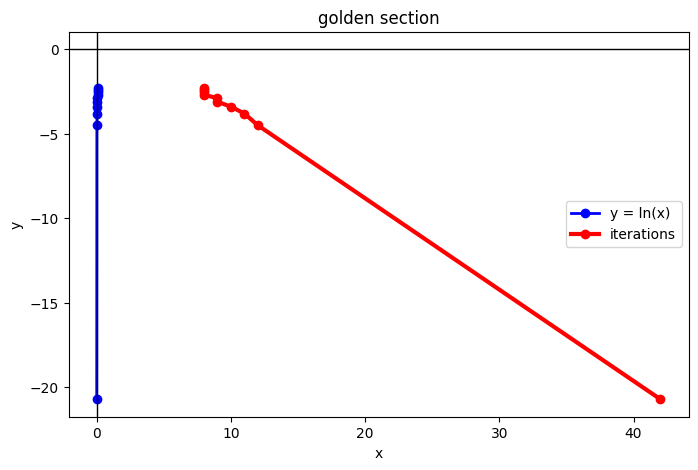

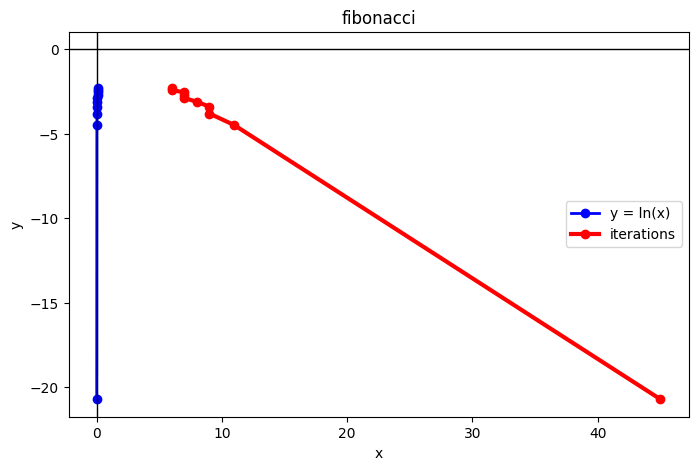

In [100]:
visualize(dichotomy, "dichotomy")
visualize(golden_section, "golden section")
visualize(fibonacci, "fibonacci")

## Вывод:
Хотя по количеству итераций побеждает метод дихотомии, но по времени выходит, что самый быстрый метод золотого сечения.